# Simulating data to build a stationary electricity model

In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import python libraries and kind framework --!

import numpy as np
from matplotlib import pyplot as plt

import utils_data

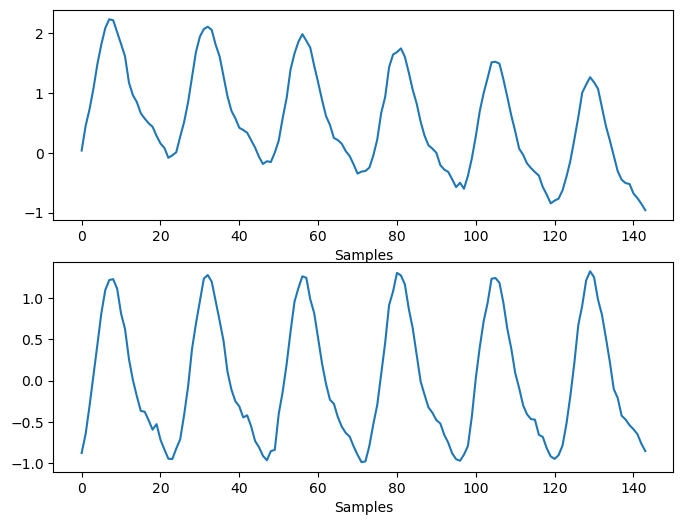

In [2]:
def sample_harm(t, f, a, a0, ns):
    u = np.stack([a0 * np.cos(2 * np.pi * f * t + a) for f, a, a0 in zip(f, a, a0)], axis=-1)
    u = np.sum(u, axis=-1, keepdims=True)
    u = u + np.random.normal(0, ns, size=u.shape)

    return u

t  = np.linspace(0, 77, 900)
ns = 0.04

# --! 3 harmonic oscillations
f  = [0.48, 0.96, 0.02]
a  = [0, np.pi/4, 0]
a0 = [1.0, 0.3, 1.0]
u1 = sample_harm(t, f, a, a0, ns)

# --! 2 harmonic oscillations
f  = [0.48, 0.96]
a  = [0, np.pi/4]
a0 = [1.0, 0.3]
u2 = sample_harm(t, f, a, a0, ns)

plt.figure(figsize=(8, 6))

plt.subplot(2,1,1)
plt.plot(u1[16:160])
plt.xlabel('Samples')

plt.subplot(2,1,2)
plt.plot(u2[16:160])
plt.xlabel('Samples')
plt.show()

In [3]:
datasaved=True

if datasaved:
    savedata     = [u1, u2]
    savedir      = '../../data/baselines/et_train_filter'
    data_nsample = 144
    utils_data.save_traindata(savedata, savedir, data_nsample)

inf >> training files saved
